Architecture: 32, Activation: tanh, Test MSE: 0.2901
Architecture: 32, Activation: relu, Test MSE: 0.2901
Architecture: 32, Activation: identity, Test MSE: 0.5076
Architecture: 64, Activation: tanh, Test MSE: 0.2943
Architecture: 64, Activation: relu, Test MSE: 0.2913
Architecture: 64, Activation: identity, Test MSE: 0.5105
Architecture: (64, 32), Activation: tanh, Test MSE: 0.2464
Architecture: (64, 32), Activation: relu, Test MSE: 0.2587
Architecture: (64, 32), Activation: identity, Test MSE: 0.5111
Architecture: (128, 64), Activation: tanh, Test MSE: 0.2579
Architecture: (128, 64), Activation: relu, Test MSE: 0.2491
Architecture: (128, 64), Activation: identity, Test MSE: 0.5128
Architecture: (128, 64, 32), Activation: tanh, Test MSE: 0.2867
Architecture: (128, 64, 32), Activation: relu, Test MSE: 0.2676
Architecture: (128, 64, 32), Activation: identity, Test MSE: 0.5164

=== Test MSE Table ===
Activation     identity      relu      tanh
Architecture                               
(

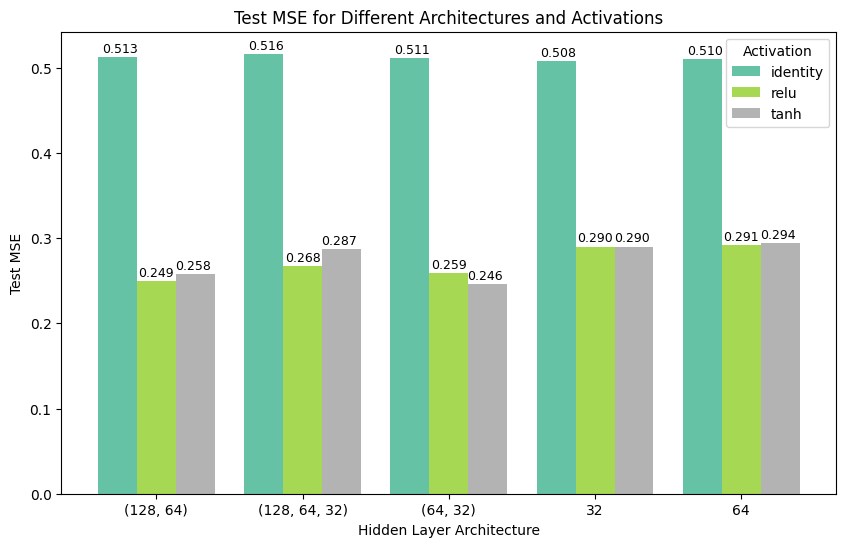

In [5]:
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd

# 1) Load and preprocess data
# 1) 加载并预处理数据
# ============================================================

# English:
# Load the California Housing dataset from sklearn.
# Chinese:
# 从 sklearn 加载加州房价数据集

data = fetch_california_housing()

# English:
# Convert the feature matrix to a pandas DataFrame for easier manipulation.
# Chinese:
# 将特征矩阵转换为 DataFrame，方便后续数据处理

X = pd.DataFrame(data.data, columns=data.feature_names)

# English:
# Convert target values (house prices) to a pandas Series.
# Chinese:
# 将房价目标值转换为 Series

y = pd.Series(data.target, name="MedHouseVal")


# ------------------------------------------------------------
# Remove missing values
# 删除缺失值
# ------------------------------------------------------------

# English:
# Remove rows containing missing values to ensure clean training data.
# Chinese:
# 删除包含缺失值的行，保证训练数据干净

X = X.dropna()
y = y.loc[X.index]


# ------------------------------------------------------------
# Split dataset into train / validation / test
# 数据集划分：训练集 / 验证集 / 测试集
# ------------------------------------------------------------

# English:
# First split data into training+validation (80%) and test set (20%).
# Chinese:
# 先将数据划分为训练+验证集（80%）和测试集（20%）

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=26
)

# English:
# Then split training+validation into actual training (72%) and validation (8%).
# Chinese:
# 再将训练+验证集划分为训练集（72%）和验证集（8%）

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1, random_state=26
)


# ------------------------------------------------------------
# Standardize features
# 特征标准化
# ------------------------------------------------------------

# English:
# Standardization rescales features so they have mean = 0 and std = 1.
# This helps neural networks train more efficiently.
# Important: fit only on the training set to avoid data leakage.
#
# Chinese:
# 标准化会让每个特征变成均值0、标准差1，
# 这样神经网络训练会更稳定、更快收敛。
# 注意：只在训练集上 fit，避免数据泄漏。

scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index
)

X_val = pd.DataFrame(
    scaler.transform(X_val),
    columns=X.columns,
    index=X_val.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)


# ============================================================
# 2) Define architectures and activation functions
# 2) 定义不同的神经网络结构和激活函数
# ============================================================

# English:
# Each tuple represents the number of neurons in hidden layers.
# Example:
# (64,32) means two hidden layers with 64 and 32 neurons.
#
# Chinese:
# 每个元组表示隐藏层结构。
# 例如：
# (64,32) 表示两个隐藏层，分别有 64 和 32 个神经元。

architectures = [
    (32),
    (64),
    (64,32),
    (128,64),
    (128,64,32)
]

# English:
# Activation functions to test.
# tanh  → nonlinear symmetric activation
# relu  → widely used deep learning activation
# identity → linear activation
#
# Chinese:
# 要测试的激活函数：
# tanh → 对称的非线性函数
# relu → 深度学习中常用激活函数
# identity → 线性激活函数

activations = ['tanh', 'relu', 'identity']


# ============================================================
# 3) Train models and collect Test MSE
# 3) 训练模型并记录测试集 MSE
# ============================================================

results = []

for arch in architectures:
    for act in activations:

        # English:
        # Create a neural network model with the current architecture
        # and activation function.
        #
        # Chinese:
        # 创建一个神经网络模型，使用当前的隐藏层结构和激活函数

        model = MLPRegressor(
            hidden_layer_sizes=arch,
            activation=act,
            solver='adam',
            learning_rate_init=1e-3,
            max_iter=700,
            random_state=26
        )

        # English:
        # Train the model on the training dataset.
        # Chinese:
        # 在训练集上训练模型

        model.fit(X_train, y_train)

        # English:
        # Predict house prices on the test set.
        # Chinese:
        # 在测试集上进行预测

        test_pred = model.predict(X_test)

        # English:
        # Compute Mean Squared Error (MSE).
        # Lower MSE indicates better prediction performance.
        #
        # Chinese:
        # 计算均方误差（MSE）。
        # MSE 越小，模型预测效果越好。

        test_mse = mean_squared_error(y_test, test_pred)

        results.append({
            'Architecture': str(arch),
            'Activation': act,
            'Test_MSE': test_mse
        })

        print(f"Architecture: {arch}, Activation: {act}, Test MSE: {test_mse:.4f}")


# ============================================================
# 4) Convert results to DataFrame
# 4) 将结果转换为表格
# ============================================================

# English:
# Convert the results list into a pandas DataFrame
# and reshape it using pivot for easier visualization.
#
# Chinese:
# 将实验结果转换为 DataFrame，
# 再使用 pivot 变成适合绘图的格式。

results_df = pd.DataFrame(results)

pivot_table = results_df.pivot(
    index='Architecture',
    columns='Activation',
    values='Test_MSE'
)

print("\n=== Test MSE Table ===")
print(pivot_table)


# ============================================================
# 5) Plot grouped bar chart
# 5) 绘制分组柱状图
# ============================================================

# English:
# Create a grouped bar chart showing Test MSE for each
# architecture and activation combination.
#
# Chinese:
# 绘制分组柱状图，
# 展示不同隐藏层结构和激活函数组合的 Test MSE。

ax = pivot_table.plot(
    kind='bar',
    figsize=(10,6),
    width=0.8,
    colormap='Set2'
)

plt.ylabel("Test MSE")
plt.xlabel("Hidden Layer Architecture")
plt.title("Test MSE for Different Architectures and Activations")
plt.xticks(rotation=0)
plt.legend(title="Activation")


# ------------------------------------------------------------
# Add value labels above bars
# 在柱子上显示具体 MSE 数值
# ------------------------------------------------------------

for i, arch in enumerate(pivot_table.index):
    for j, act in enumerate(pivot_table.columns):
        mse = pivot_table.loc[arch, act]

        ax.text(
            i + j*0.25 - 0.25,
            mse + 0.002,
            f"{mse:.3f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.show()